## Velocity ROM + Surrogate Models (POD + ML)

This notebook builds a POD (SVD) reduced-order model for the velocity field using CFD snapshots (`steady_state_Re*.csv`).
Then it learns a surrogate mapping `Re -> POD coefficients` and reconstructs `ux` at an untrained Reynolds number (`Re=725`).

Coefficient surrogate models compared (3 total):
- POD + Dense Neural Network regressor
- POD + Random Forest regressor (multi-output)
- POD + Gradient Boosting regressor (multi-output)


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import os

In [5]:
Re_train = [100,500,1000,1500,2000,2500,3000,3500,4000,4500,5000]   
data_dir = os.getcwd()

ux_s = []

for Re in Re_train:
    filename = os.path.join(data_dir, f"steady_state_Re{Re}.csv")
    df = pd.read_csv(filename)
    ux = df['ux'].values  
    ux_s.append(ux)

X = np.array(ux_s)   
print(X.shape)

(11, 13312)


In [6]:
X_mean = X.mean(axis=0)
X_centered = X - X_mean
print(X_centered.shape)

(11, 13312)


In [7]:
n_modes = 2
svd = TruncatedSVD(n_components=n_modes)
coefficients = svd.fit_transform(X_centered)  
print(coefficients.shape)
modes = svd.components_   
print(modes.shape)

(11, 2)
(2, 13312)


In [8]:
Re_array = np.array(Re_train).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split( Re_array, coefficients, test_size=0.2,random_state=42)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)
y_train = scaler_Y.fit_transform(y_train)
y_test  = scaler_Y.transform(y_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(n_modes)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=2,
    verbose=1
)
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.6f}")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 1.4429 - mae: 1.0621 - val_loss: 7.0863 - val_mae: 1.7788
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9174 - mae: 0.8049 - val_loss: 6.9779 - val_mae: 1.7610
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.1403 - mae: 0.9181 - val_loss: 6.8475 - val_mae: 1.7429
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0240 - mae: 0.8900 - val_loss: 6.7304 - val_mae: 1.7263
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8516 - mae: 0.7886 - val_loss: 6.6153 - val_mae: 1.7096
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9338 - mae: 0.8469 - val_loss: 6.5045 - val_mae: 1.6946
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9350 - mae: 0.8024 - val_loss: 6.3850 - val_mae: 1.6789
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5711 - mae: 0.6553 - val_loss: 6.2968 - val_mae: 1.6653
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6854 - mae: 

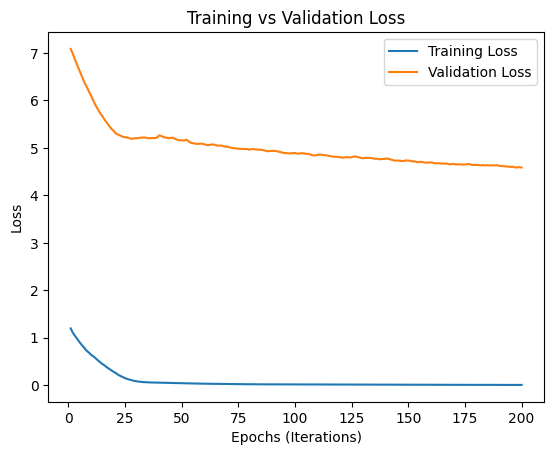

In [9]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure()
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs (Iterations)')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [10]:
Re_new = 725

# -----------------------------
# 1) POD + Dense NN (existing model)
# -----------------------------
Re_new_norm = scaler_X.transform([[Re_new]])

a_pred_nn_norm = model.predict(Re_new_norm)
a_pred_nn = scaler_Y.inverse_transform(a_pred_nn_norm).flatten()

ux_pred_nn = a_pred_nn @ modes + X_mean

# -----------------------------
# 2) POD + Random Forest (multi-output regressor)
# -----------------------------
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

rf = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=300, random_state=42)
)
rf.fit(Re_array, coefficients)

a_pred_rf = rf.predict([[Re_new]]).flatten()
ux_pred_rf = a_pred_rf @ modes + X_mean

# -----------------------------
# 3) POD + Gradient Boosting (multi-output regressor)
# -----------------------------
gb = MultiOutputRegressor(
    GradientBoostingRegressor(random_state=42)
)
gb.fit(Re_array, coefficients)

a_pred_gb = gb.predict([[Re_new]]).flatten()
ux_pred_gb = a_pred_gb @ modes + X_mean

# Keep variable names expected by downstream cells
# (cell 9 reconstructs ux_pred from `a_pred`)
a_pred = a_pred_nn
ux_pred_nn = ux_pred_nn  # explicit; cell 11 compares multiple predictions

print("Predicted POD coefficients at Re=725:")
print("  NN coefficients:", a_pred_nn)
print("  RF coefficients:", a_pred_rf)
print("  GB coefficients:", a_pred_gb)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted POD coefficients at Re=725:
  NN coefficients: [-7.515029  -6.0607867]
  RF coefficients: [-10.51597438  -5.389014  ]
  GB coefficients: [-11.46348456  -6.78365834]


In [11]:
ux_pred = a_pred @ modes + X_mean
print(ux_pred.flatten())

[0.9901808  0.98978479 0.9904398  ... 0.01573805 0.17581098 0.01550771]


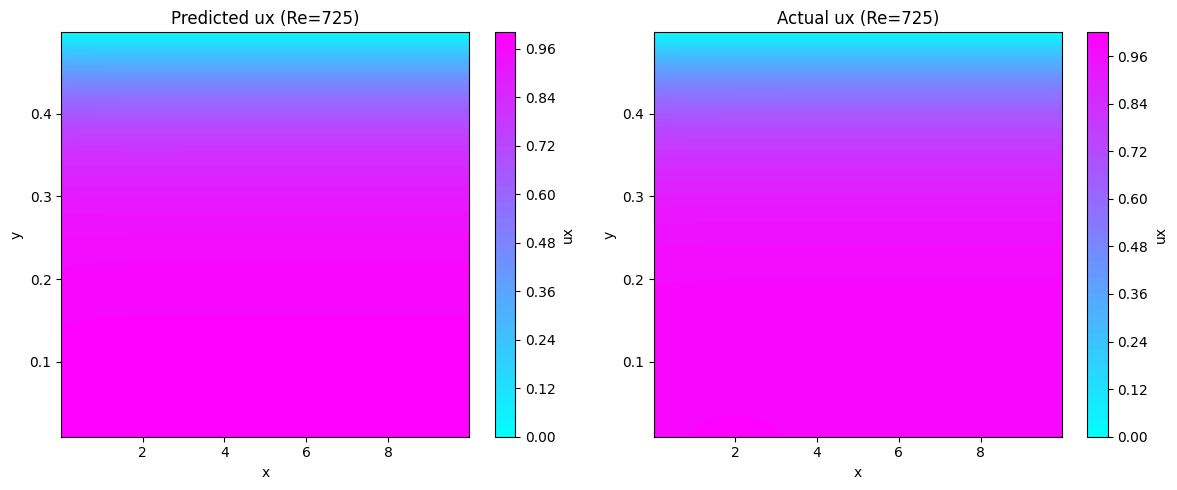

In [13]:
df_ref = pd.read_csv("steady_state_Re725.csv")
x = df_ref['x'].values
y = df_ref['y'].values
ux_true = df_ref['ux'].values

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.tricontourf(x, y, ux_pred, levels=50,cmap='cool')
plt.colorbar(label="ux")
plt.title(f"Predicted ux (Re={Re_new})")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1,2,2)
plt.tricontourf(x, y, ux_true, levels=50,cmap='cool')
plt.colorbar(label="ux")
plt.title(f"Actual ux (Re={Re_new})")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

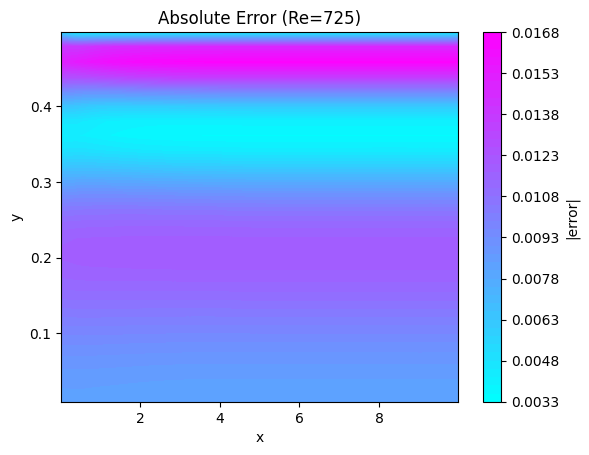

L2 Error (NN): 1.1334653089853755
L2 Error (RF): 4.10279098266327
L2 Error (GB): 4.970436905152901


In [14]:
# Plot absolute error for the NN prediction (keeps original visualization)
error = np.abs(ux_true - ux_pred)

plt.figure()
plt.tricontourf(x, y, error, levels=50, cmap='cool')
plt.colorbar(label="|error|")
plt.title(f"Absolute Error (Re={Re_new})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

l2_nn = np.linalg.norm(ux_true - ux_pred)
print("L2 Error (NN):", l2_nn)

# Compare against the other POD-coefficient surrogates we trained in cell 8
try:
    l2_rf = np.linalg.norm(ux_true - ux_pred_rf)
    l2_gb = np.linalg.norm(ux_true - ux_pred_gb)
    print("L2 Error (RF):", l2_rf)
    print("L2 Error (GB):", l2_gb)
except NameError:
    print("(RF/GB predictions not found; only NN error computed.)")

Points in slice: 52


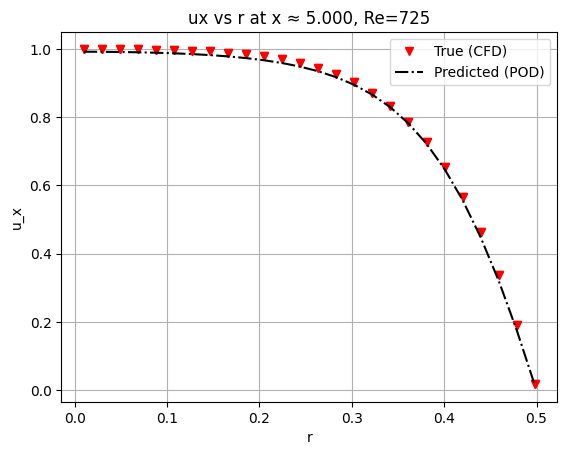

L2 error: 0.07096419554021587


In [15]:
R = 0.5

x_target = np.median(x)


mask = np.isclose(x, x_target, atol=1e-2)

print("Points in slice:", mask.sum())


y_slice_true = y[mask]
ux_slice_true = ux_true[mask]


y_slice_pred = y[mask]
ux_slice_pred = ux_pred[mask]


r_true = np.abs(y_slice_true)
r_pred = np.abs(y_slice_pred)


idx_true = np.argsort(r_true)
r_true = r_true[idx_true]
ux_true_sorted = ux_slice_true[idx_true]

idx_pred = np.argsort(r_pred)
r_pred = r_pred[idx_pred]
ux_pred_sorted = ux_slice_pred[idx_pred]

plt.figure()

plt.plot(r_true, ux_true_sorted, 'v',color='r', label="True (CFD)")
plt.plot(r_pred, ux_pred_sorted, '-.',color='k', label="Predicted (POD)")

plt.xlabel("r")
plt.ylabel("u_x")
plt.title(f"ux vs r at x ≈ {x_target:.3f}, Re={Re_new}")
plt.legend()
plt.grid()

plt.show()

error = np.linalg.norm(ux_true_sorted - ux_pred_sorted)
print("L2 error:", error)

## Pressure-drop models (dp) at untrained Reynolds number (Re=725)

This section uses the pressure-field snapshots (`steady_state_Re*.csv`) to build surrogate models for the pressure-drop metric `dp` and evaluates them at an untrained Reynolds number `Re=725`.

Models inside `train_pressure_drop_models.py`:
- POD(pressure) + Dense Neural Network (coeff surrogate) (if `tensorflow` is available)
- POD(pressure) + Random Forest (coeff surrogate)
- Direct Gradient Boosting: `Re -> dp`

Data dir: c:\Users\pradi\OneDrive\Desktop\CHL-514 final project
Train Re: [100, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
Val Re: [725]
dp masks: x_up=2.00195, x_down=7.97852, tol=0.00977

Re=725:
  dp_true      = 0.5965585769230768
  dp_pred_nn   = 0.596626
  dp_pred_rf   = 0.596577
  dp_pred_direct = 0.596458
  dp_pred_nn abs_err=6.69543e-05, rel_err=0.000112234
  dp_pred_rf abs_err=1.8124e-05, rel_err=3.0381e-05
  dp_pred_direct abs_err=0.000100849, rel_err=0.000169052

Saved: c:\Users\pradi\OneDrive\Desktop\CHL-514 final project\dp_model_results.csv
Saved plot: c:\Users\pradi\OneDrive\Desktop\CHL-514 final project\dp_models_plot.png
    Re   dp_true  dp_pred_nn  dp_pred_rf  dp_pred_direct
0  725  0.596559    0.596626    0.596577        0.596458

Re=725.0 true dp=0.5965585769230768
  dp_pred_nn: pred=0.596626, abs_err=6.69543e-05, rel_err=0.000112234
  dp_pred_rf: pred=0.596577, abs_err=1.8124e-05, rel_err=3.0381e-05
  dp_pred_direct: pred=0.596458, abs_err=0.000100

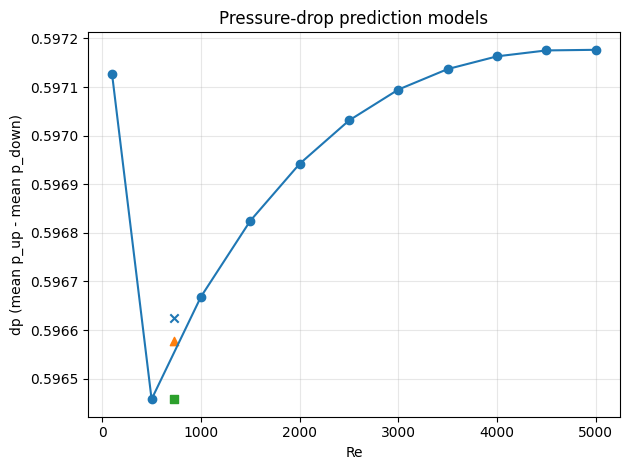

In [16]:
# Pressure-drop model run (appended section)

import os
import pandas as pd

from train_pressure_drop_models import main as run_dp_models

# Train/evaluate dp surrogates and save results
run_dp_models()

df_dp = pd.read_csv(os.path.join(os.getcwd(), "dp_model_results.csv"))
print(df_dp)

# Quick view: print numeric errors if dp_true is available
if "dp_true" in df_dp.columns:
    for _, row in df_dp.iterrows():
        re_val = row.get("Re")
        dp_true = row.get("dp_true")
        print(f"\nRe={re_val} true dp={dp_true}")
        for col in ["dp_pred_nn", "dp_pred_rf", "dp_pred_direct"]:
            if col in df_dp.columns:
                pred = row.get(col)
                if pd.notna(dp_true) and pd.notna(pred):
                    err = abs(pred - dp_true)
                    rel = err / abs(dp_true) if dp_true != 0 else float("nan")
                    print(f"  {col}: pred={pred:.6g}, abs_err={err:.6g}, rel_err={rel:.6g}")